# ALM Toolkit — Liability-Driven Immunization

This notebook applies the core library to a real ALM problem: given a **liability** (a future obligation) and a set of candidate **bonds**, find the portfolio whose value moves in step with the liability as interest rates change — so the obligation stays funded.

本 notebook 將核心程式庫應用於一個真實的 ALM 問題：給定一筆**負債**（未來義務）與一組候選**債券**，找出一個價值能隨利率變動與負債同步移動的組合——使該義務始終有足額資產支應。

We use **Redington immunization** (match present value and duration, maximize convexity) and demonstrate the stronger **full immunization** that survives large rate shocks.

我們採用 **Redington 免疫**（匹配現值與存續期間、最大化凸度），並展示更強的、能承受大幅利率衝擊的**全免疫**。

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from alm.core.cashflow import CashFlow
from alm.core.risk import present_value_at_yield
from alm.applications.immunization import Bond, immunize

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

## The Problem

A pension fund owes a single payment of **1,000,000** in **10 years**. It can invest in three zero-coupon bonds maturing at 5, 10, and 20 years. We want a portfolio that:

- has the same present value as the liability (fully funded today), and
- has the same duration (first-order rate risk cancels),

while maximizing convexity for extra protection against large rate moves.

某退休基金需在 **10 年後**支付一筆 **1,000,000** 的給付。它可投資於 5 年、10 年、20 年到期的三檔零息債券。我們要找一個組合，使其現值與負債相同（今日足額提存）、存續期間與負債相同（一階利率風險抵銷），同時最大化凸度以增強對大幅利率變動的保護。

In [2]:
y = 0.04  # flat valuation yield

# Liability: a single 1,000,000 payment due in 10 years.
liability = CashFlow(times=[10], amounts=[1_000_000])

# Candidate bonds: zero-coupon bonds maturing at 5, 10, 20 years.
def zero_bond(maturity, face=100):
    return Bond(cashflow=CashFlow(times=[maturity], amounts=[face]), y=y)

bonds = [zero_bond(5), zero_bond(10), zero_bond(20)]
labels = ["5y zero", "10y zero", "20y zero"]

result = immunize(liability, bonds, y)

print(f"Solver success: {result.success}")
print(f"Liability PV:   {present_value_at_yield(liability, y):,.2f}\n")
print("Immunizing portfolio (PV allocated to each bond):")
for label, w in zip(labels, result.weights):
    print(f"  {label:>9}: {w:>14,.2f}")
print(f"\nAsset convexity:     {result.asset_convexity:.4f}")
print(f"Liability convexity: {result.liability_convexity:.4f}")
print(f"Convexity condition satisfied: {result.convexity_satisfied}")

Solver success: True
Liability PV:   670,320.05

Immunizing portfolio (PV allocated to each bond):
    5y zero:     446,880.03
   10y zero:           0.00
   20y zero:     223,440.02

Asset convexity:     150.0000
Liability convexity: 100.0000
Convexity condition satisfied: True


## Does It Work? Stress-Testing Against Rate Shocks

The true test of immunization: shock the yield up and down, and check that the **surplus** (asset value minus liability value) stays at or above zero. A well-immunized portfolio's surplus should sit at zero at the current yield and curve gently upward on both sides — protected against rate moves in either direction.

免疫是否有效的真正考驗：將殖利率上下衝擊，檢查**盈餘**（資產價值減負債價值）是否維持在零或以上。一個良好免疫的組合，其盈餘應在當前殖利率處為零、並在兩側平緩地向上彎曲——對雙向的利率變動都受到保護。

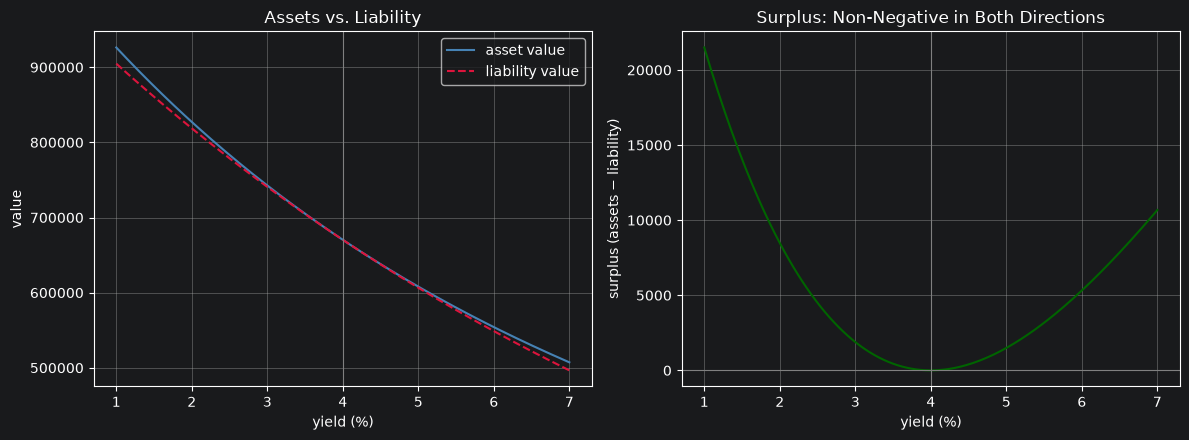

In [3]:
# Convert PV weights into units of each bond, then revalue under rate shocks.
units = [w / b.pv for w, b in zip(result.weights, bonds)]

shocks = np.linspace(-0.03, 0.03, 200)
asset_vals, liab_vals, surplus_vals = [], [], []

for ds in shocks:
    rate = y + ds
    assets = sum(u * present_value_at_yield(b.cashflow, rate)
                 for u, b in zip(units, bonds))
    liab = present_value_at_yield(liability, rate)
    asset_vals.append(assets)
    liab_vals.append(liab)
    surplus_vals.append(assets - liab)

asset_vals = np.array(asset_vals)
liab_vals = np.array(liab_vals)
surplus_vals = np.array(surplus_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: asset value vs. liability value across the shock range.
ax1.plot((y + shocks) * 100, asset_vals, label="asset value", color="steelblue")
ax1.plot((y + shocks) * 100, liab_vals, label="liability value",
         color="crimson", linestyle="--")
ax1.axvline(y * 100, color="gray", lw=0.8)
ax1.set_xlabel("yield (%)")
ax1.set_ylabel("value")
ax1.set_title("Assets vs. Liability")
ax1.legend()

# Right: the surplus — the heart of immunization.
ax2.plot((y + shocks) * 100, surplus_vals, color="darkgreen")
ax2.axhline(0, color="gray", lw=0.8)
ax2.axvline(y * 100, color="gray", lw=0.8)
ax2.set_xlabel("yield (%)")
ax2.set_ylabel("surplus (assets − liability)")
ax2.set_title("Surplus: Non-Negative in Both Directions")

plt.tight_layout()
plt.show()

---

## Summary

Starting from a liability and three candidate bonds, the toolkit built a portfolio that is fully funded, duration-matched, and convexity-maximized — and stress-testing confirms its surplus stays non-negative across a ±300bp range of parallel rate shocks. The optimizer's choice of a **barbell** (5y + 20y, skipping 10y) is the linear program maximizing convexity: under a fixed duration, spreading cash flows to the extremes raises convexity, by the same Jensen's-inequality logic that makes convexity a `t²`-weighting.

從一筆負債與三檔候選債券出發，工具組建構出一個足額提存、存續期間匹配、凸度最大化的組合——壓力測試確認其盈餘在 ±300 個基點的平行利率衝擊範圍內維持非負。最佳化器選擇**啞鈴組合**（5 年 + 20 年、跳過 10 年），正是線性規劃最大化凸度的結果：在固定存續期間下，將現金流分散至兩端可提高凸度，背後是使凸度成為 `t²` 加權的同一個 Jensen 不等式邏輯。